In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import joblib

In [3]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

df["Churn"] = df["Churn"].map(
    {"Yes":1, "No":0}
)

df.head()

C:\Users\KIIT\AppData\Local\Temp\ipykernel_10760\1322439304.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [5]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [9]:
preprocessor = joblib.load("models/preprocessor.pkl")

print("Loaded")

Loaded


In [8]:
import os

print(os.getcwd())
print(os.listdir("models"))

C:\Users\KIIT\churnsense
['preprocessor.pkl']


In [14]:
models = {

    "Logistic Regression":
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ),

    "Decision Tree":
    DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )
}

In [15]:
results = []

trained_models = {}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, clf in models.items():

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", clf)
    ])

    cv_score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    results.append([
        name,
        cv_score.mean(),
        auc,
        acc,
        precision,
        recall,
        f1
    ])

    trained_models[name] = pipe

In [16]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "CV_AUC",
        "Test_AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df.sort_values(
    by="Test_AUC",
    ascending=False
)

,Model,CV_AUC,Test_AUC,Accuracy,Precision,Recall,F1
3,Gradient Boosting,0.848060,0.846059,0.801278,0.670290,0.494652,0.569231
0,Logistic Regression,0.845354,0.840063,0.753016,0.523985,0.759358,0.620087
1,Decision Tree,0.818499,0.839079,0.742370,0.509182,0.815508,0.626927
2,Random Forest,0.825004,0.819196,0.784244,0.615132,0.500000,0.551622
4,XGBoost,0.825316,0.817858,0.779986,0.596386,0.529412,0.560907


In [17]:
best_model_name = results_df.sort_values(
    by="Test_AUC",
    ascending=False
).iloc[0]["Model"]

print(best_model_name)

Gradient Boosting


In [18]:
best_model = trained_models[
    best_model_name
]

y_pred = best_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [20]:
joblib.dump(
    best_model,
    "models/best_model.pkl"
)

print("Best model saved")

Best model saved


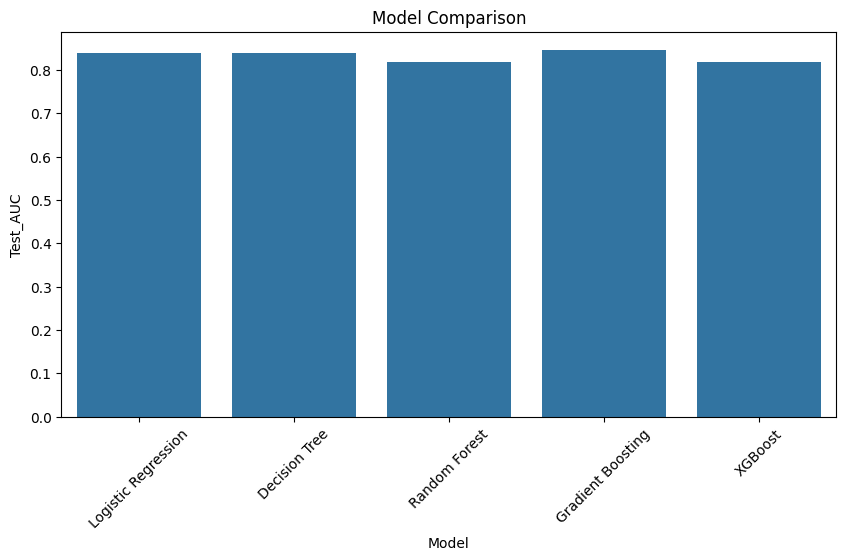

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Test_AUC",
    data=results_df
)

plt.xticks(rotation=45)

plt.title(
    "Model Comparison"
)

plt.show()